# M6-B1 — Analyse de dérive (à compléter)

## 1. Exploration — distributions référence vs prod

Variables numériques (8): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Variables catégorielles (6): ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']


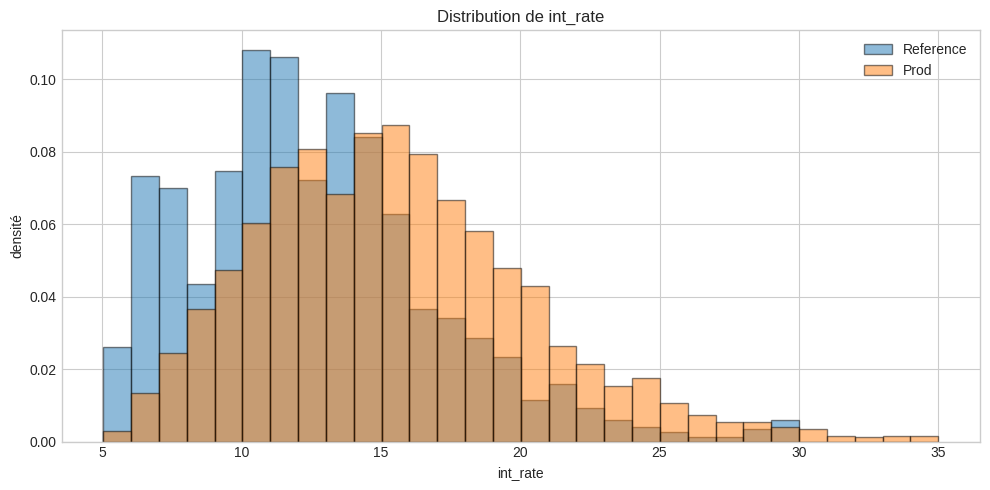

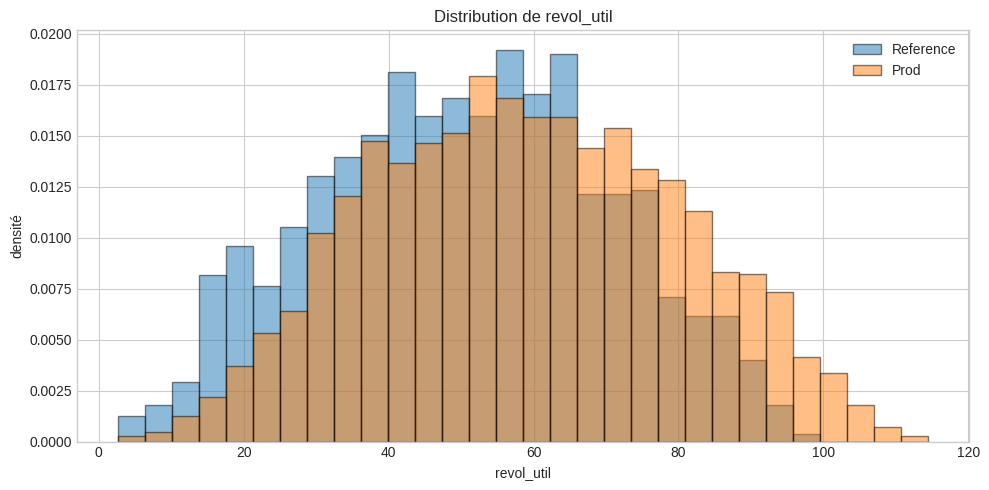

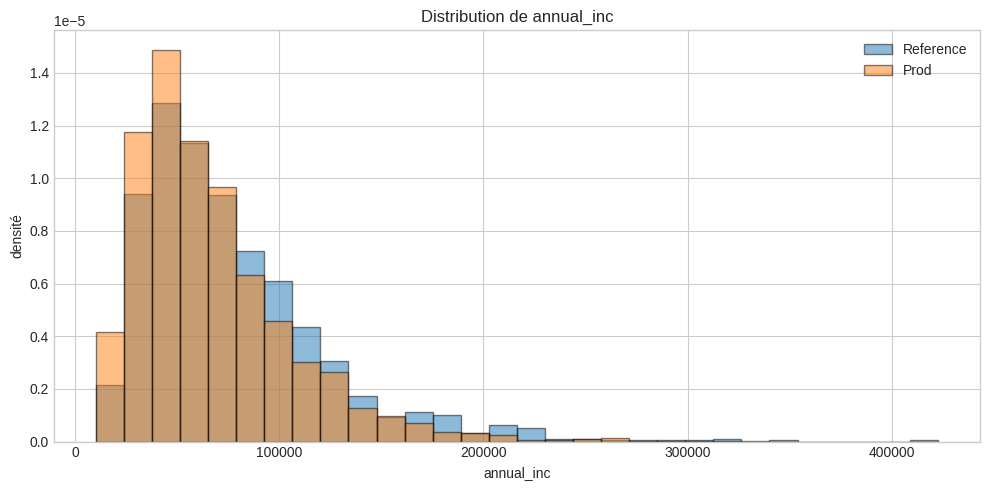

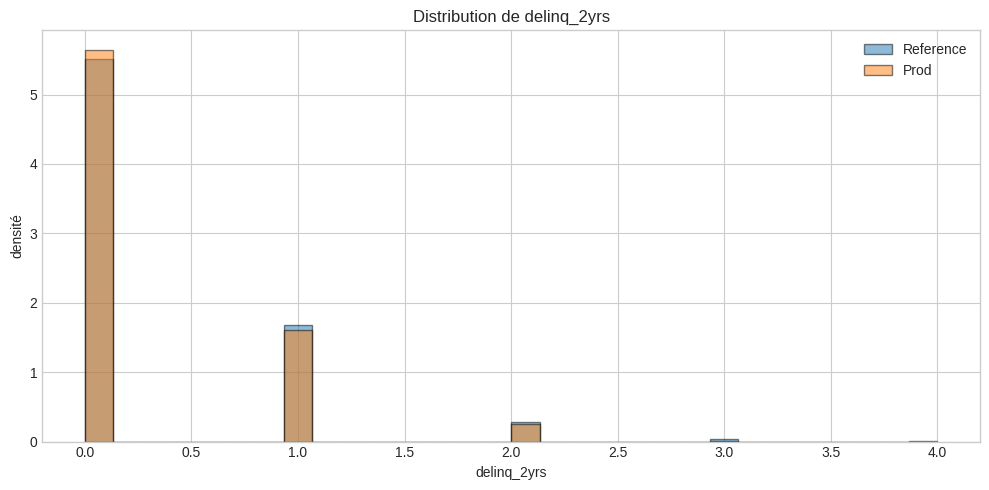

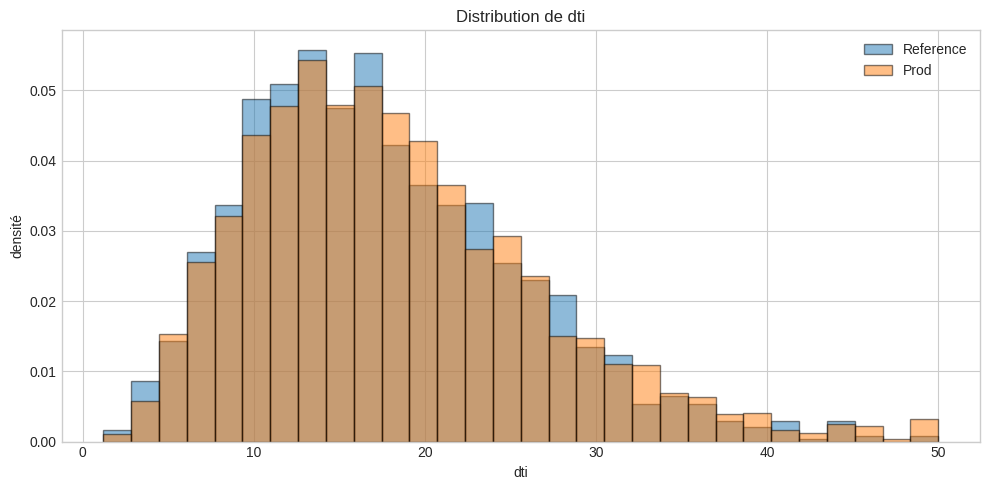

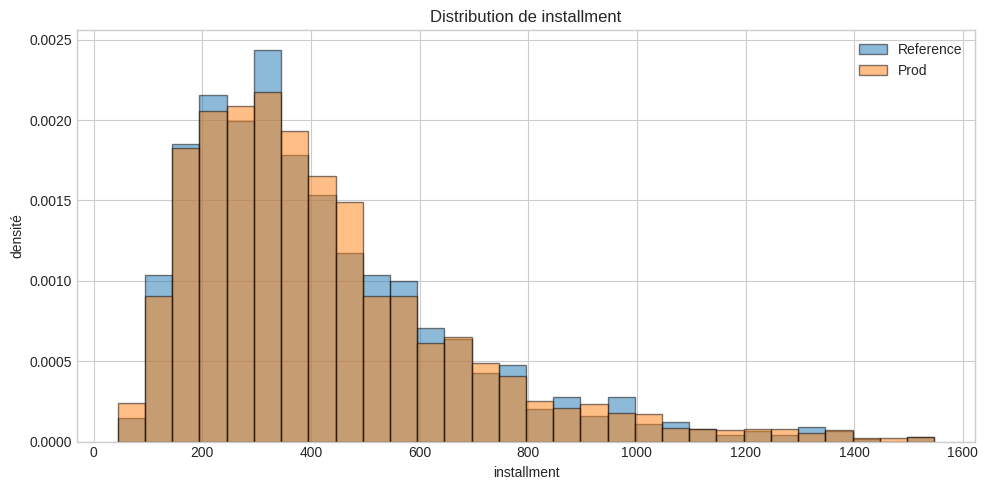

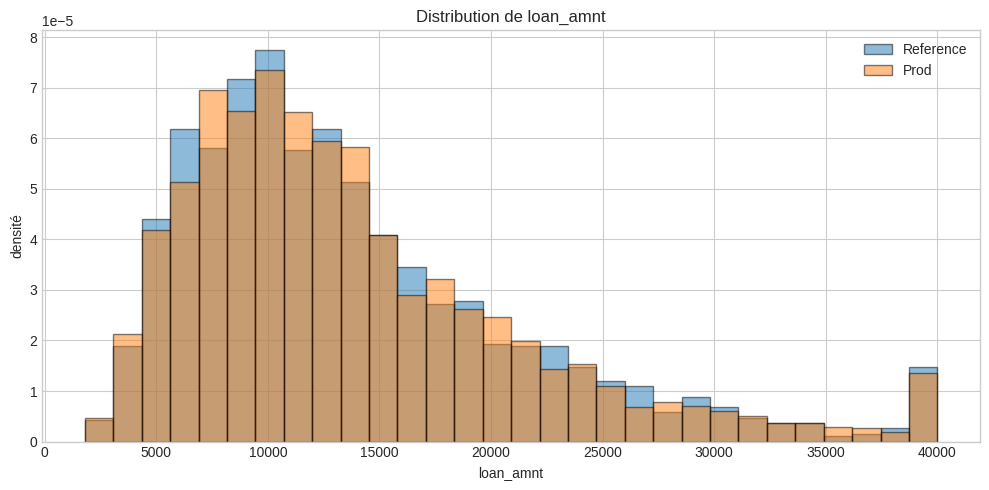

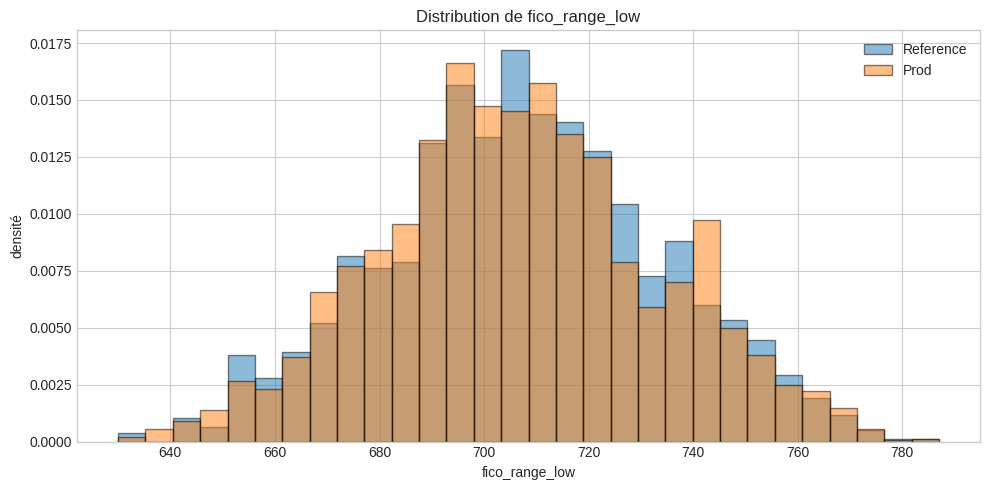

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

root = Path.cwd().resolve().parent
ref = pd.read_csv(root / "data" / "reference_set.csv")
prod = pd.read_csv(root / "data" / "prod_3months.csv")

# --- 0) Préparation ---
exclude_cols = {"loan_status", "timestamp"}
feature_cols = [c for c in ref.columns if c not in exclude_cols and c in prod.columns]

numeric_cols = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(ref[c]) and pd.api.types.is_numeric_dtype(prod[c])
]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f"Variables numériques ({len(numeric_cols)}): {numeric_cols}")
print(f"Variables catégorielles ({len(categorical_cols)}): {categorical_cols}")

# --- 1) Comparaison visuelle des distributions numériques ---
# Représentation en superposition transparente.
priority_cols = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]

for col in [c for c in priority_cols if c in numeric_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Les autres variables numériques peuvent aussi être vérifiées rapidement.
for col in [c for c in numeric_cols if c not in priority_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()



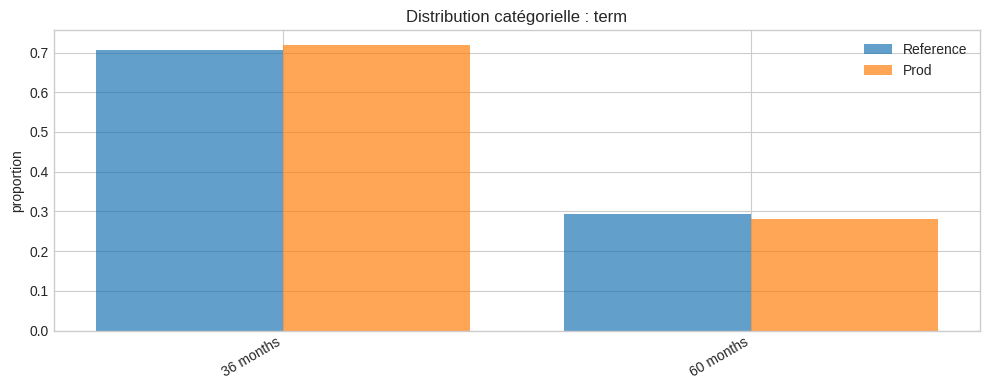

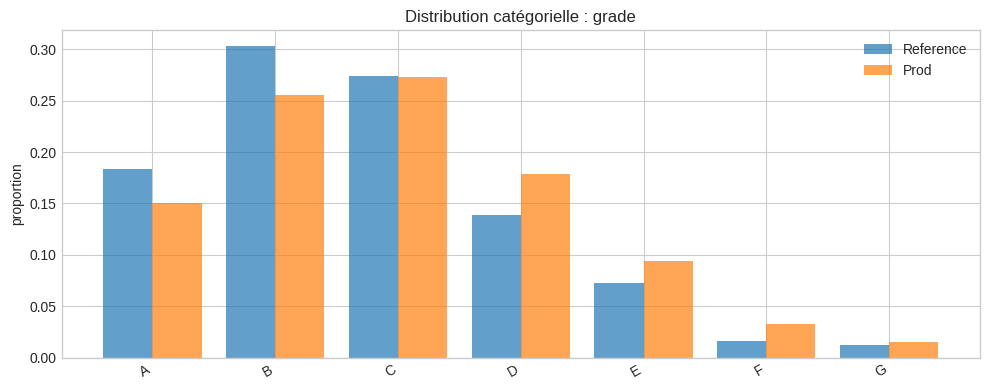

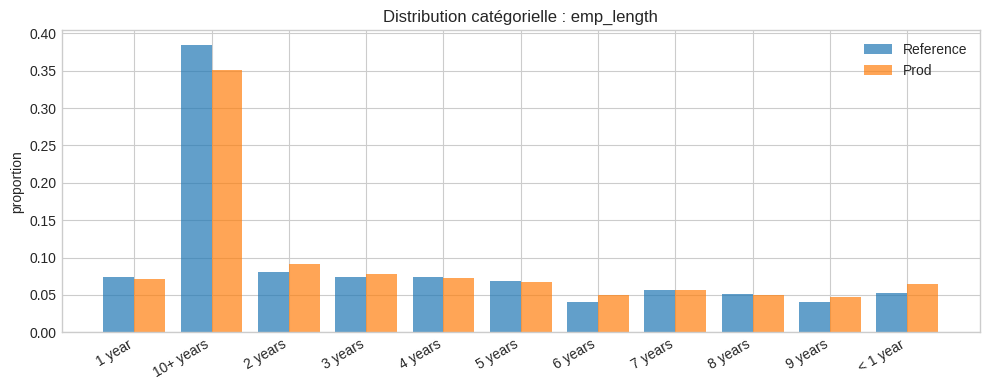

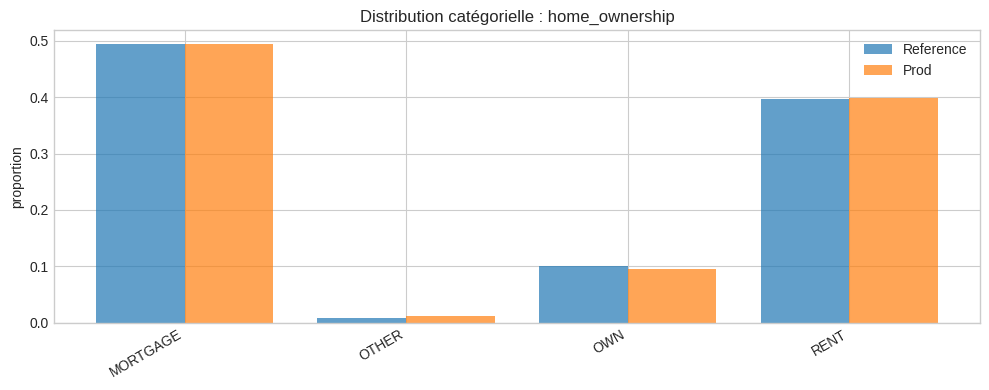

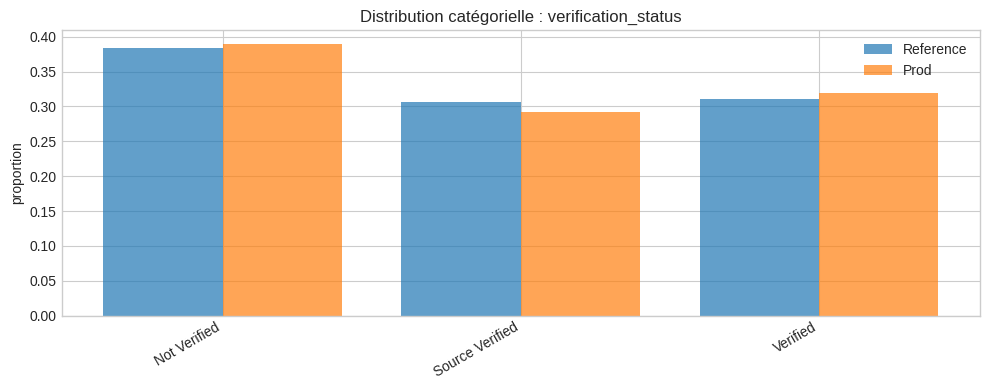

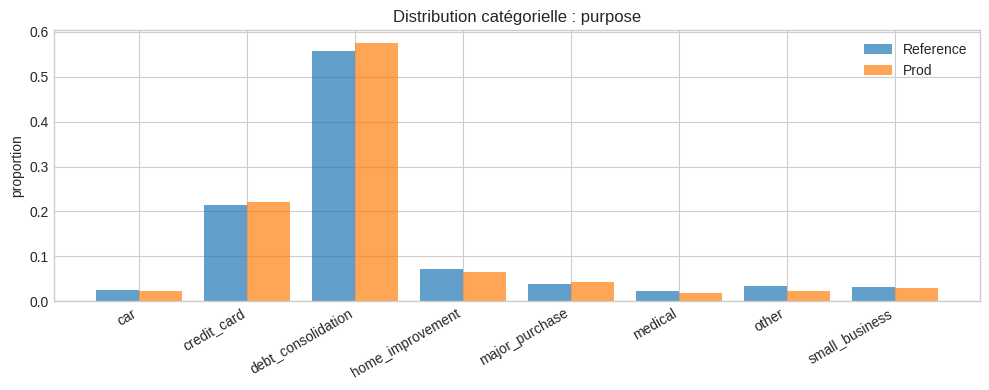

In [2]:
# --- 2) Comparaison des variables catégorielles ---
for col in categorical_cols:
    ref_counts = ref[col].dropna().astype(str).value_counts(normalize=True)
    prod_counts = prod[col].dropna().astype(str).value_counts(normalize=True)
    categories = sorted(set(ref_counts.index) | set(prod_counts.index), key=lambda x: str(x))

    ref_prop = ref_counts.reindex(categories, fill_value=0)
    prod_prop = prod_counts.reindex(categories, fill_value=0)

    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - 0.2, ref_prop.values, width=0.4, alpha=0.7, label="Reference")
    ax.bar(x + 0.2, prod_prop.values, width=0.4, alpha=0.7, label="Prod")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylabel("proportion")
    ax.set_title(f"Distribution catégorielle : {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()



In [3]:
# --- 3) Résumé quantitatif pour repérer les écarts importants ---
summary = []
for col in numeric_cols:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    summary.append({
        "feature": col,
        "ref_mean": round(ref_vals.mean(), 3),
        "prod_mean": round(prod_vals.mean(), 3),
        "ref_median": round(ref_vals.median(), 3),
        "prod_median": round(prod_vals.median(), 3),
        "ref_std": round(ref_vals.std(), 3),
        "prod_std": round(prod_vals.std(), 3),
        "missing_ref": round(ref[col].isna().mean(), 3),
        "missing_prod": round(prod[col].isna().mean(), 3),
    })

summary_df = pd.DataFrame(summary)
print("\nRésumé descriptif des variables numériques :")
print(summary_df.to_string(index=False))

# --- 4) Features à examiner en premier ---
priority = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]
print("\nColonnes à prioriser pour l'investigation :")
print([c for c in priority if c in numeric_cols])




Résumé descriptif des variables numériques :
       feature  ref_mean  prod_mean  ref_median  prod_median   ref_std  prod_std  missing_ref  missing_prod
     loan_amnt 13828.400  13800.067    11900.00    11900.000  7761.013  7680.036        0.000         0.000
      int_rate    12.613     15.499       12.01       15.085     4.473     4.924        0.000         0.000
   installment   417.861    421.532      354.45      362.560   246.171   249.186        0.000         0.000
    annual_inc 76938.400  67156.464    65950.00    57935.500 45641.436 39129.825        0.000         0.000
           dti    17.564     18.201       16.48       16.945     8.048     8.491        0.000         0.000
   delinq_2yrs     0.312      0.282        0.00        0.000     0.562     0.524        0.000         0.000
fico_range_low   707.366    706.686      707.00      706.000    26.371    26.632        0.000         0.000
    revol_util    50.574     58.962       50.90       58.400    20.013    21.162        0.

## 2. Détection statistique — PSI · KS · Chi²

In [4]:
import sys

sys.path.append(str(root))

from src.drift_detection import PSI_DRIFT, PSI_STABLE, drift_report

ALPHA = 0.05  # seuil de significativité, côté analyse


In [5]:
report = drift_report(ref, prod, numeric_cols, categorical_cols)

print(f"{len(report)} features testées "
      f"({len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles)")

display(report.style
        .format({"psi": "{:.3f}", "ks_pvalue": "{:.2e}", "chi2_pvalue": "{:.2e}"})
        .background_gradient(subset=["psi"], cmap="OrRd"))

14 features testées (8 numériques, 6 catégorielles)


,type,psi,ks_pvalue,chi2_pvalue,verdict
feature,,,,,
int_rate,numerique,0.444,4.63e-65,nan,dérive
revol_util,numerique,0.187,3.82e-20,nan,suspect
annual_inc,numerique,0.067,2.28e-09,nan,stable
grade,categorielle,0.043,nan,3.65e-07,stable
installment,numerique,0.015,6.63e-01,nan,stable
dti,numerique,0.011,1.10e-01,nan,stable
emp_length,categorielle,0.010,nan,4.92e-01,stable
purpose,categorielle,0.009,nan,1.99e-01,stable
fico_range_low,numerique,0.007,4.89e-01,nan,stable


In [6]:
# --- Correction des tests multiples (Holm-Bonferroni) ---
# Sur N features à alpha = 0.05, P(au moins un faux positif) = 1 - 0.95**N
# (~58 % pour 17 features). Sans correction, "tout dérive" est garanti.
# Fonction PURE : elle renvoie une copie enrichie, ne mute pas `report`.
# La cellule d'export peut donc la rappeler seule, dans n'importe quel ordre.


def enrich_report(report: pd.DataFrame, alpha: float = ALPHA) -> pd.DataFrame:
    enriched = report.copy()
    enriched["p_value"] = enriched["ks_pvalue"].fillna(enriched["chi2_pvalue"])

    ordered = enriched["p_value"].dropna().sort_values()
    n_tests, significant, rejecting = len(ordered), {}, True
    for rank, (feature, p) in enumerate(ordered.items()):
        rejecting = rejecting and (p <= alpha / (n_tests - rank))
        significant[feature] = rejecting  # dès qu'un test échoue, les suivants aussi
    enriched["signif_holm"] = pd.Series(significant).reindex(enriched.index).fillna(False)

    def commentaire(row: pd.Series) -> str:
        """L'ampleur commande, la p-value confirme."""
        if row["verdict"] == "stable":
            return ("significativité portée par la taille d'échantillon, ampleur faible"
                    if row["signif_holm"] else "aucun signal")
        if row["type"] == "numerique":
            mean_ref = ref[row.name].mean()
            if mean_ref:
                shift = 100 * (prod[row.name].mean() - mean_ref) / abs(mean_ref)
                return f"signaux concordants, moyenne {shift:+.1f} %"
        return "signaux concordants, modalités redistribuées"

    enriched["commentaire"] = enriched.apply(commentaire, axis=1)
    return enriched


enriched = enrich_report(report)
print(f"significatives brut : {int((enriched['p_value'] < ALPHA).sum())} | "
      f"après Holm : {int(enriched['signif_holm'].sum())}")

display(enriched[["type", "psi", "p_value", "signif_holm", "verdict", "commentaire"]]
        .style.format({"psi": "{:.3f}", "p_value": "{:.2e}"}))

significatives brut : 4 | après Holm : 4


,type,psi,p_value,signif_holm,verdict,commentaire
feature,,,,,,
int_rate,numerique,0.444,4.63e-65,True,dérive,"signaux concordants, moyenne +22.9 %"
revol_util,numerique,0.187,3.82e-20,True,suspect,"signaux concordants, moyenne +16.6 %"
annual_inc,numerique,0.067,2.28e-09,True,stable,"significativité portée par la taille d'échantillon, ampleur faible"
grade,categorielle,0.043,3.65e-07,True,stable,"significativité portée par la taille d'échantillon, ampleur faible"
installment,numerique,0.015,6.63e-01,False,stable,aucun signal
dti,numerique,0.011,1.10e-01,False,stable,aucun signal
emp_length,categorielle,0.010,4.92e-01,False,stable,aucun signal
purpose,categorielle,0.009,1.99e-01,False,stable,aucun signal
fico_range_low,numerique,0.007,4.89e-01,False,stable,aucun signal


In [7]:
# --- Export du tableau de synthèse : drift_summary.md ---
# On ré-enrichit ici : la cellule est autonome, elle ne dépend que de `report`.
enriched = enrich_report(report)

export = enriched.reset_index()[
    ["feature", "type", "psi", "p_value", "signif_holm", "verdict", "commentaire"]
].rename(columns={"psi": "PSI", "p_value": "p-value", "signif_holm": "signif. (Holm)"})
export["PSI"] = export["PSI"].round(3)
export["p-value"] = export["p-value"].map(lambda p: f"{p:.2e}" if pd.notna(p) else "—")


def to_markdown_table(df: pd.DataFrame) -> str:
    """Table markdown sans dépendance : `DataFrame.to_markdown` exige `tabulate`,
    qui n'est pas garanti dans l'environnement du correcteur."""
    header = "| " + " | ".join(map(str, df.columns)) + " |"
    separator = "|" + "|".join(["---"] * len(df.columns)) + "|"
    rows = ["| " + " | ".join(map(str, row)) + " |" for row in df.astype(str).to_numpy()]
    return "\n".join([header, separator, *rows])


top = enriched.index[enriched["psi"] > PSI_STABLE][:3].tolist()
header = f"""# Synthèse de détection de dérive — M6-B1

Référence : `reference_set.csv` ({len(ref)} lignes) · Production : `prod_3months.csv` ({len(prod)} lignes)
Features testées : {len(enriched)} ({len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles) — exhaustif.
Seuils PSI (repères conventionnels, pas des frontières) : < {PSI_STABLE} stable · {PSI_STABLE}-{PSI_DRIFT} suspect · > {PSI_DRIFT} dérive.
Tests multiples corrigés par Holm-Bonferroni à alpha = {ALPHA}.
Calculs : `src/drift_detection.py`, couvert par `tests/`.

"""
footer = f"""

## Synthèse globale

{int((enriched["psi"] > PSI_DRIFT).sum())} feature(s) au-delà de PSI {PSI_DRIFT}, {int(enriched["psi"].between(PSI_STABLE, PSI_DRIFT).sum())} en zone suspecte.
Features les plus déplacées : {", ".join(f"`{f}`" for f in top) or "aucune"}.

_(2-3 lignes d'interprétation métier à rédiger ici.)_

> Un chiffre n'est pas un verdict, un verdict n'est pas un diagnostic.
"""
(root / "drift_summary.md").write_text(header + to_markdown_table(export) + footer, encoding="utf-8")
print(to_markdown_table(export))

| feature | type | PSI | p-value | signif. (Holm) | verdict | commentaire |
|---|---|---|---|---|---|---|
| int_rate | numerique | 0.444 | 4.63e-65 | True | dérive | signaux concordants, moyenne +22.9 % |
| revol_util | numerique | 0.187 | 3.82e-20 | True | suspect | signaux concordants, moyenne +16.6 % |
| annual_inc | numerique | 0.067 | 2.28e-09 | True | stable | significativité portée par la taille d'échantillon, ampleur faible |
| grade | categorielle | 0.043 | 3.65e-07 | True | stable | significativité portée par la taille d'échantillon, ampleur faible |
| installment | numerique | 0.015 | 6.63e-01 | False | stable | aucun signal |
| dti | numerique | 0.011 | 1.10e-01 | False | stable | aucun signal |
| emp_length | categorielle | 0.01 | 4.92e-01 | False | stable | aucun signal |
| purpose | categorielle | 0.009 | 1.99e-01 | False | stable | aucun signal |
| fico_range_low | numerique | 0.007 | 4.89e-01 | False | stable | aucun signal |
| loan_amnt | numerique | 0.003 | 9.89e-01 

## 3. Calibration en exploitation

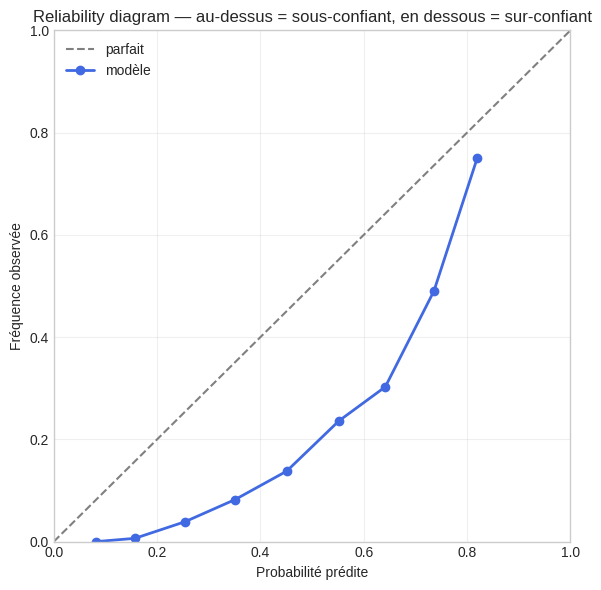

Brier score = 0.2211   ECE = 0.2844
 bin     conf      acc  count       gap
   1 0.082472 0.000000     18 -0.082472
   2 0.157098 0.006369    157 -0.150729
   3 0.253964 0.038835    309 -0.215129
   4 0.351020 0.082251    462 -0.268769
   5 0.450766 0.137763    617 -0.313003
   6 0.552072 0.236264    728 -0.315808
   7 0.641663 0.302691    446 -0.338972
   8 0.735839 0.490196    255 -0.245643
   9 0.819538 0.750000      8 -0.069538

Verdict : le modèle est sur-confiant.


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------
# 1) Charger les prédictions
# ---------------------------
root_candidates = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]

csv_path = None
for root in root_candidates:
    candidate = root / "data" / "predictions_log.csv"
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("Fichier introuvable : data/predictions_log.csv")

df = pd.read_csv(csv_path)

required_cols = {"proba_default", "true_label"}
missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Colonnes manquantes : {sorted(missing)}")

p_all = df["proba_default"].clip(0, 1).astype(float)
y_all = df["true_label"].astype(int)

# ---------------------------
# 2) Score de calibration
# ---------------------------
# Brier score : moyenne de (y - p)^2
brier_score = ((y_all - p_all) ** 2).mean()

# ---------------------------
# 3) Reliability diagram
# ---------------------------
def reliability(proba: pd.Series, y_true: pd.Series, n_bins: int = 10) -> tuple[pd.DataFrame, float, float]:
    """Retourne (table par bin, brier_score, ece).

    Bins de largeur fixe 0.1. `gap = acc - conf` : positif = sous-confiant,
    négatif = sur-confiant.
    """
    proba = pd.Series(proba).clip(0, 1).astype(float).reset_index(drop=True)
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    brier = float(((y_true - proba) ** 2).mean())

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(proba, bins[:-1], right=False)
    rows = []
    for i in range(1, n_bins + 1):
        mask = bin_ids == i
        if not mask.any():
            continue
        conf, acc = proba[mask].mean(), y_true[mask].mean()
        rows.append({"bin": i, "conf": conf, "acc": acc,
                     "count": int(mask.sum()), "gap": acc - conf})

    table = pd.DataFrame(rows)
    ece = float(((table["count"] / len(proba)) * table["gap"].abs()).sum())
    return table, brier, ece


def verdict_calibration(table: pd.DataFrame, ece: float) -> str:
    """Sur-confiant / sous-confiant / bien calibré."""
    mean_gap = table["gap"].mean()
    if ece < 0.05 and abs(mean_gap) < 0.05:
        return "bien calibré"
    return "sur-confiant" if mean_gap < 0 else "sous-confiant"


cal, brier_score, ece_global = reliability(p_all, y_all)

# ---------------------------
# 4) Graphe
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="parfait")
ax.plot(cal["conf"], cal["acc"], marker="o", linewidth=2, color="royalblue", label="modèle")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Probabilité prédite")
ax.set_ylabel("Fréquence observée")
ax.set_title("Reliability diagram — au-dessus = sous-confiant, en dessous = sur-confiant")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Interprétation
# ---------------------------
# Cas 1 : points au-dessus de la diagonale => sous-confiant
# Cas 2 : points en dessous de la diagonale => sur-confiant
# Cas 3 : points proches de la diagonale => bien calibré

print(f"Brier score = {brier_score:.4f}   ECE = {ece_global:.4f}")
print(cal.to_string(index=False))
print(f"\nVerdict : le modèle est {verdict_calibration(cal, ece_global)}.")

## 4. Performance dans le temps

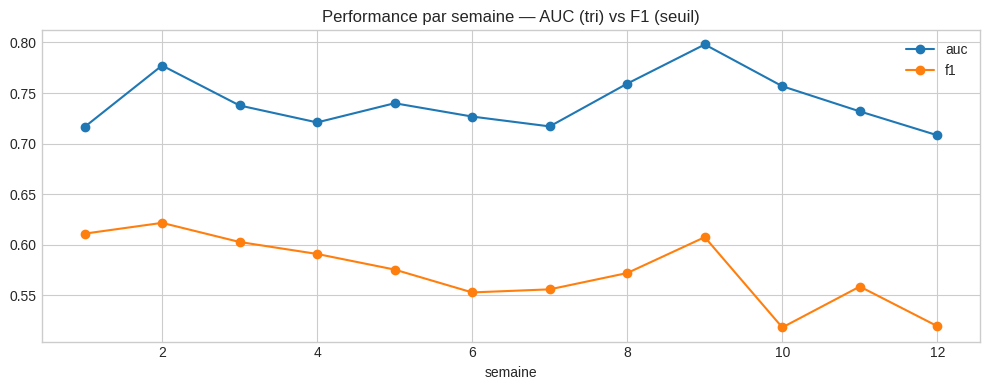

,n,prevalence,auc,f1
semaine,,,,
1,226.0,0.212,0.716,0.611
2,293.0,0.164,0.777,0.622
3,236.0,0.242,0.738,0.603
4,248.0,0.202,0.721,0.591
5,234.0,0.167,0.740,0.575
6,269.0,0.186,0.727,0.553
7,254.0,0.169,0.717,0.556
8,243.0,0.160,0.759,0.572
9,233.0,0.215,0.798,0.607


In [16]:
# --- Axe 2 : pouvoir de tri dans le temps ---
from sklearn.metrics import f1_score, roc_auc_score

logs = df.copy()
logs["timestamp"] = pd.to_datetime(logs["timestamp"])
logs["semaine"] = ((logs["timestamp"] - logs["timestamp"].min()).dt.days // 7) + 1

weekly = logs.groupby("semaine").apply(
    lambda g: pd.Series({
        "n": len(g),
        "prevalence": g["true_label"].mean(),
        "auc": roc_auc_score(g["true_label"], g["proba_default"])
               if g["true_label"].nunique() > 1 else float("nan"),
        "f1": f1_score(g["true_label"], (g["proba_default"] >= 0.5).astype(int),
                       average="macro", zero_division=0),
    }),
    include_groups=False,
)

fig, ax = plt.subplots(figsize=(10, 4))
weekly[["auc", "f1"]].plot(ax=ax, marker="o")
ax.set_title("Performance par semaine — AUC (tri) vs F1 (seuil)")
ax.set_xlabel("semaine")
ax.legend()
plt.tight_layout()
plt.show()

display(weekly.round(3))

In [11]:
# --- Début vs fin de période ---
# L'AUC mesure le tri indépendamment du seuil ; le F1 dépend du seuil ET de la prévalence.
DELTA_AUC_TOLERE = 0.03

debut, fin = weekly.loc[1:4], weekly.loc[9:12]
axe_auc = pd.DataFrame({
    "semaines 1-4": debut[["auc", "f1"]].mean(),
    "semaines 9-12": fin[["auc", "f1"]].mean(),
})
axe_auc["delta"] = axe_auc["semaines 9-12"] - axe_auc["semaines 1-4"]
display(axe_auc.round(3))

delta_auc = axe_auc.loc["auc", "delta"]
auc_stable = abs(delta_auc) < DELTA_AUC_TOLERE
print(f"AUC {'stable' if auc_stable else 'dégradée'} (Δ={delta_auc:+.3f}) — "
      f"{'compatible data drift, à croiser PSI + calibration' if auc_stable else 'investiguer : concept drift ? population ? qualité ?'}")

,semaines 1-4,semaines 9-12,delta
auc,0.738,0.749,0.011
f1,0.606,0.551,-0.056


AUC stable (Δ=+0.011) — compatible data drift, à croiser PSI + calibration


## 5. Diagnostic & recommandation

In [12]:
# --- Triangulation des 4 axes ---
# Aucun axe ne prouve seul : le diagnostic naît du faisceau.

# Axe 1 — features (section 2)
features_derive = enriched.index[enriched["verdict"] != "stable"].tolist()

# Axe 3 — calibration : a-t-elle dérivé entre le début et la fin ?
logs_debut, logs_fin = logs[logs["semaine"] <= 4], logs[logs["semaine"] >= 9]
cal_debut, brier_debut, ece_debut = reliability(logs_debut["proba_default"], logs_debut["true_label"])
cal_fin, brier_fin, ece_fin = reliability(logs_fin["proba_default"], logs_fin["true_label"])
calibration_degradee = ece_fin > ece_debut * 1.5

# Axe 4 — temporalité : tendance progressive ou rupture brutale ?
# Une dérive marché est graduelle ; un bug ETL fait un saut datable.
# On suit la numérique la plus déplacée (le suivi hebdo suppose une échelle).
top_feature = enriched.index[0]
numeriques_derive = [f for f in enriched.index if f in numeric_cols]
feature_suivie = numeriques_derive[0] if numeriques_derive else None

if feature_suivie and "timestamp" in prod.columns:
    semaines = ((pd.to_datetime(prod["timestamp"])
                 - pd.to_datetime(prod["timestamp"]).min()).dt.days // 7) + 1
    serie = prod.groupby(semaines)[feature_suivie].mean()
    amplitude = serie.max() - serie.min()
    part_du_saut = (serie.diff().abs().max() / amplitude) if amplitude else 0.0
    temporalite = "rupture brutale" if part_du_saut > 0.5 else "tendance progressive"
else:
    feature_suivie, part_du_saut, temporalite = None, float("nan"), "non évaluable"

print(f"""Features qui dérivent : {", ".join(features_derive) or "aucune"}
  (PSI max = {enriched["psi"].max():.3f} sur `{top_feature}`)
AUC début : {axe_auc.loc["auc", "semaines 1-4"]:.3f}   AUC fin : {axe_auc.loc["auc", "semaines 9-12"]:.3f}   ΔAUC : {delta_auc:+.3f}
F1 début : {axe_auc.loc["f1", "semaines 1-4"]:.3f}   F1 fin : {axe_auc.loc["f1", "semaines 9-12"]:.3f}   ΔF1 : {axe_auc.loc["f1", "delta"]:+.3f}
Calibration (ECE) : {ece_debut:.3f} ({verdict_calibration(cal_debut, ece_debut)}) → {ece_fin:.3f} ({verdict_calibration(cal_fin, ece_fin)})
Temporalité : {temporalite} sur `{feature_suivie}` (le plus gros saut hebdo porte {part_du_saut:.0%} de l'amplitude)""")

Features qui dérivent : int_rate, revol_util
  (PSI max = 0.444 sur `int_rate`)
AUC début : 0.738   AUC fin : 0.749   ΔAUC : +0.011
F1 début : 0.606   F1 fin : 0.551   ΔF1 : -0.056
Calibration (ECE) : 0.240 (sur-confiant) → 0.315 (sur-confiant)
Temporalité : tendance progressive sur `int_rate` (le plus gros saut hebdo porte 18% de l'amplitude)


In [15]:
# --- Fiche de diagnostic ---
# Le script coche ; c'est le binôme qui argumente et qui tranche.
if not features_derive and auc_stable:
    diagnostic = "pas de signal significatif"
elif features_derive and auc_stable:
    diagnostic = "data drift plausible"
elif features_derive and not auc_stable:
    diagnostic = "data drift avec impact — concept drift à investiguer"
else:
    diagnostic = "concept drift à investiguer (features stables, AUC en baisse)"

if temporalite == "rupture brutale":
    diagnostic += " + problème de qualité / ETL à investiguer"
if calibration_degradee:
    diagnostic += " + impact sur la calibration"

fiche = f"""# Diagnostic — M6-B1

## Diagnostic retenu
**{diagnostic}**

## Preuves
- Axe 1 (features) : {len(features_derive)} feature(s) dérivent, PSI max {enriched["psi"].max():.3f} sur `{top_feature}`.
- Axe 2 (AUC) : ΔAUC {delta_auc:+.3f} sur seuil de tolérance {DELTA_AUC_TOLERE} → tri {"préservé" if auc_stable else "dégradé"}.
- Axe 3 (calibration) : ECE {ece_debut:.3f} → {ece_fin:.3f}, Brier {brier_debut:.4f} → {brier_fin:.4f} ; modèle {verdict_calibration(cal_debut, ece_debut)} puis {verdict_calibration(cal_fin, ece_fin)}.
- Axe 4 (temporalité) : {temporalite} sur `{feature_suivie}` ({part_du_saut:.0%} de l'amplitude sur un seul saut hebdo).
- Contrôle : le F1 varie de {axe_auc.loc["f1", "delta"]:+.3f} — un F1 en baisse à AUC stable s'explique par le seuil, pas par la relation X → Y.

## Ce qui manquerait pour être certain
- Les labels des dernières semaines ne sont mûrs qu'après le délai de constatation du défaut : la fenêtre récente est peu observable pour le concept drift.
- Trois mois ne permettent pas de réfuter l'hypothèse saisonnière de Sophie Léger (il faudrait un historique pluriannuel).
- Les labels ne portent que sur les dossiers acceptés : biais de sélection non corrigé.
"""
(root / "diagnostic.md").write_text(fiche, encoding="utf-8")
print(fiche)

# Diagnostic — M6-B1

## Diagnostic retenu
**data drift plausible**

## Preuves
- Axe 1 (features) : 2 feature(s) dérivent, PSI max 0.444 sur `int_rate`.
- Axe 2 (AUC) : ΔAUC +0.011 sur seuil de tolérance 0.03 → tri préservé.
- Axe 3 (calibration) : ECE 0.240 → 0.315, Brier 0.2021 → 0.2421 ; modèle sur-confiant puis sur-confiant.
- Axe 4 (temporalité) : tendance progressive sur `int_rate` (18% de l'amplitude sur un seul saut hebdo).
- Contrôle : le F1 varie de -0.056 — un F1 en baisse à AUC stable s'explique par le seuil, pas par la relation X → Y.

## Ce qui manquerait pour être certain
- Les labels des dernières semaines ne sont mûrs qu'après le délai de constatation du défaut : la fenêtre récente est peu observable pour le concept drift.
- Trois mois ne permettent pas de réfuter l'hypothèse saisonnière de Sophie Léger (il faudrait un historique pluriannuel).
- Les labels ne portent que sur les dossiers acceptés : biais de sélection non corrigé.

